In [293]:

import os
import random
import time
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error
)
from sklearn.datasets import load_diabetes

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

import torchvision.transforms.functional as TF

warnings.filterwarnings("ignore")

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed:", SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Random seed: 42
Device: cuda
GPU: Tesla T4


In [294]:

Data_dir = "/kaggle/input/datasets/zalando-research/fashionmnist"

train_csv = os.path.join(Data_dir, "fashion-mnist_train.csv")
test_csv = os.path.join(Data_dir, "fashion-mnist_test.csv")

train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

print("Training dataframe:", train_df.shape)
print("Test dataframe:", test_df.shape)

display(train_df.head())


Training dataframe: (60000, 785)
Test dataframe: (10000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [295]:

Label_col = "label"

X_all = train_df.drop(columns=[Label_col]).values.astype(np.float32)
y_all = train_df[Label_col].values.astype(np.int64)

X_test = test_df.drop(columns=[Label_col]).values.astype(np.float32)
y_test = test_df[Label_col].values.astype(np.int64)

# Normalise pixels from [0, 255] to [0, 1]
X_all /= 255.0
X_test /= 255.0

# Flatten explicitly
X_all = X_all.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("Minimum pixel value:", X_all.min())
print("Maximum pixel value:", X_all.max())

X_all shape: (60000, 784)
y_all shape: (60000,)
X_test shape: (10000, 784)
y_test shape: (10000,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [296]:

X_train, X_val, y_train, y_val = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    stratify=y_all,
    random_state=SEED
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 48000
Validation samples: 12000
Test samples: 10000


In [297]:

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

distribution = pd.DataFrame({
    "Class": range(10),
    "Class name": class_names,
    "Training": np.bincount(y_train, minlength=10),
    "Validation": np.bincount(y_val, minlength=10),
    "Test": np.bincount(y_test, minlength=10)
})

display(distribution)

,Class,Class name,Training,Validation,Test
0,0,T-shirt/top,4800,1200,1000
1,1,Trouser,4800,1200,1000
2,2,Pullover,4800,1200,1000
3,3,Dress,4800,1200,1000
4,4,Coat,4800,1200,1000
5,5,Sandal,4800,1200,1000
6,6,Shirt,4800,1200,1000
7,7,Sneaker,4800,1200,1000
8,8,Bag,4800,1200,1000
9,9,Ankle boot,4800,1200,1000


In [298]:

def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(np.float32)


def softmax(x):
    # Numerical stability
    shifted = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(shifted)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


def one_hot(y, num_classes=10):
    result = np.zeros((len(y), num_classes), dtype=np.float32)
    result[np.arange(len(y)), y] = 1.0
    return result


def initialize_numpy_network(seed=42):
    rng = np.random.default_rng(seed)

    # He initialization for ReLU
    W1 = (
        rng.standard_normal((784, 64)).astype(np.float32)
        * np.sqrt(2.0 / 784)
    )

    b1 = np.zeros((1, 64), dtype=np.float32)

    W2 = (
        rng.standard_normal((64, 10)).astype(np.float32)
        * np.sqrt(2.0 / 64)
    )

    b2 = np.zeros((1, 10), dtype=np.float32)

    return W1, b1, W2, b2


def numpy_forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    probs = softmax(z2)

    cache = {
        "X": X,
        "z1": z1,
        "a1": a1,
        "z2": z2,
        "probs": probs
    }

    return probs, cache


def cross_entropy_loss(probs, y):
    n = len(y)

    # Avoid log(0)
    clipped = np.clip(probs, 1e-12, 1.0)

    return -np.mean(
        np.log(clipped[np.arange(n), y])
    )


def numpy_backward(y, cache, W2):
    X = cache["X"]
    z1 = cache["z1"]
    a1 = cache["a1"]
    probs = cache["probs"]

    n = len(y)

    # dL/dz2
    dz2 = probs.copy()
    dz2[np.arange(n), y] -= 1
    dz2 /= n

    # Output layer
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    # Hidden layer
    da1 = dz2 @ W2.T
    dz1 = da1 * relu_derivative(z1)

    # First layer
    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    grads = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return grads

In [299]:

# Select 5,000 samples
X_5000, _, y_5000, _ = train_test_split(
    X_train,
    y_train,
    train_size=5000,
    stratify=y_train,
    random_state=SEED
)

W1, b1, W2, b2 = initialize_numpy_network(SEED)

learning_rate = 0.1
epochs = 20
batch_size = 128

numpy_losses = []

rng = np.random.default_rng(SEED)

for epoch in range(epochs):

    indices = rng.permutation(len(X_5000))

    epoch_loss = 0
    batches = 0

    for start in range(0, len(X_5000), batch_size):

        batch_idx = indices[start:start + batch_size]

        X_batch = X_5000[batch_idx]
        y_batch = y_5000[batch_idx]

        # Forward
        probs, cache = numpy_forward(
            X_batch,
            W1,
            b1,
            W2,
            b2
        )

        # Loss
        loss = cross_entropy_loss(
            probs,
            y_batch
        )

        # Backward
        grads = numpy_backward(
            y_batch,
            cache,
            W2
        )

        # Manual gradient descent
        W1 -= learning_rate * grads["dW1"]
        b1 -= learning_rate * grads["db1"]

        W2 -= learning_rate * grads["dW2"]
        b2 -= learning_rate * grads["db2"]

        epoch_loss += loss
        batches += 1

    epoch_loss /= batches
    numpy_losses.append(epoch_loss)

    print(
        f"Epoch {epoch+1:02d}/{epochs} "
        f"- Loss: {epoch_loss:.4f}"
    )

Epoch 01/20 - Loss: 1.3256
Epoch 02/20 - Loss: 0.8530
Epoch 03/20 - Loss: 0.7296
Epoch 04/20 - Loss: 0.6880
Epoch 05/20 - Loss: 0.6520
Epoch 06/20 - Loss: 0.5862
Epoch 07/20 - Loss: 0.5628
Epoch 08/20 - Loss: 0.5818
Epoch 09/20 - Loss: 0.5301
Epoch 10/20 - Loss: 0.5042
Epoch 11/20 - Loss: 0.5100
Epoch 12/20 - Loss: 0.4965
Epoch 13/20 - Loss: 0.4895
Epoch 14/20 - Loss: 0.4726
Epoch 15/20 - Loss: 0.4658
Epoch 16/20 - Loss: 0.4824
Epoch 17/20 - Loss: 0.4538
Epoch 18/20 - Loss: 0.4198
Epoch 19/20 - Loss: 0.4119
Epoch 20/20 - Loss: 0.4306


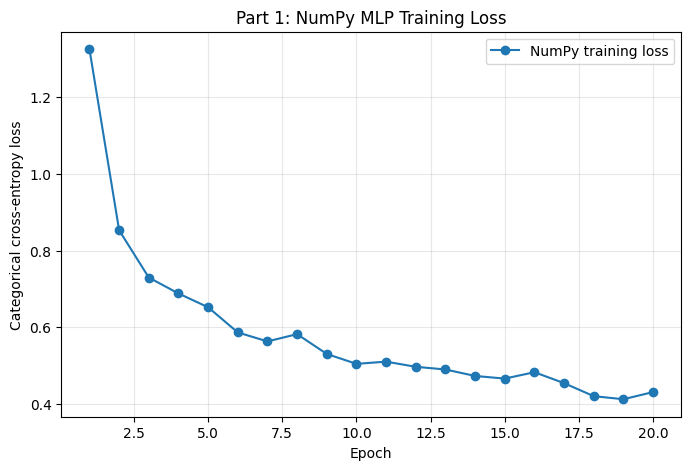

In [300]:

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    numpy_losses,
    marker="o",
    label="NumPy training loss"
)

plt.xlabel("Epoch")
plt.ylabel("Categorical cross-entropy loss")
plt.title("Part 1: NumPy MLP Training Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [301]:

class TwoLayerTorch(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# Use a fixed batch
X_check = X_5000[:128]
y_check = y_5000[:128]

# Fresh NumPy initialization
W1_check, b1_check, W2_check, b2_check = (
    initialize_numpy_network(SEED)
)

# NumPy forward/backward
numpy_probs, numpy_cache = numpy_forward(
    X_check,
    W1_check,
    b1_check,
    W2_check,
    b2_check
)

numpy_grads = numpy_backward(
    y_check,
    numpy_cache,
    W2_check
)

# PyTorch

torch_model = TwoLayerTorch().to(device)

with torch.no_grad():

    torch_model.fc1.weight.copy_(
        torch.tensor(W1_check.T, device=device)
    )

    torch_model.fc1.bias.copy_(
        torch.tensor(b1_check.flatten(), device=device)
    )

    torch_model.fc2.weight.copy_(
        torch.tensor(W2_check.T, device=device)
    )

    torch_model.fc2.bias.copy_(
        torch.tensor(b2_check.flatten(), device=device)
    )

X_tensor = torch.tensor(
    X_check,
    dtype=torch.float32,
    device=device
)

y_tensor = torch.tensor(
    y_check,
    dtype=torch.long,
    device=device
)

criterion = nn.CrossEntropyLoss()

torch_logits = torch_model(X_tensor)
torch_loss = criterion(torch_logits, y_tensor)

torch_model.zero_grad()
torch_loss.backward()

# Convert PyTorch gradients to NumPy orientation
torch_dW1 = (
    torch_model.fc1.weight.grad
    .detach()
    .cpu()
    .numpy()
    .T
)

torch_dW2 = (
    torch_model.fc2.weight.grad
    .detach()
    .cpu()
    .numpy()
    .T
)

# Compare
diff_W1 = np.max(
    np.abs(numpy_grads["dW1"] - torch_dW1)
)

diff_W2 = np.max(
    np.abs(numpy_grads["dW2"] - torch_dW2)
)

diff_b1 = np.max(
    np.abs(
        numpy_grads["db1"].flatten()
        - torch_model.fc1.bias.grad.detach().cpu().numpy()
    )
)

diff_b2 = np.max(
    np.abs(
        numpy_grads["db2"].flatten()
        - torch_model.fc2.bias.grad.detach().cpu().numpy()
    )
)

print("Maximum absolute gradient differences:")
print(f"W1: {diff_W1:.10f}")
print(f"b1: {diff_b1:.10f}")
print(f"W2: {diff_W2:.10f}")
print(f"b2: {diff_b2:.10f}")

print("\nOverall maximum difference:",
      max(diff_W1, diff_b1, diff_W2, diff_b2))

Maximum absolute gradient differences:
W1: 0.0000000088
b1: 0.0000000065
W2: 0.0000000186
b2: 0.0000000079

Overall maximum difference: 1.8569638743359818e-08


The maximum absolute gradient difference between the NumPy implementation and PyTorch's autograd, across W1, b1, W2, and b2, was 1.86e-8. This is well within float32 numerical precision (differences below roughly 1e-6 are expected from rounding alone), so the manual forward pass, backward pass, and gradient computation are confirmed correct.

Part 2

In [302]:

class ActivationMLP(nn.Module):

    def __init__(self, activation="relu"):
        super().__init__()

        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

        self.activation_name = activation

    def activation(self, x):

        if self.activation_name == "sigmoid":
            return torch.sigmoid(x)

        elif self.activation_name == "tanh":
            return torch.tanh(x)

        elif self.activation_name == "relu":
            return F.relu(x)

        elif self.activation_name == "leaky_relu":
            return F.leaky_relu(x, negative_slope=0.01)

        else:
            raise ValueError("Unknown activation")

    def forward(self, x):

        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)

        return x

In [303]:

def create_loaders(
    X_train_data,
    y_train_data,
    X_val_data,
    y_val_data,
    batch_size=256
):

    train_dataset = TensorDataset(
        torch.tensor(X_train_data, dtype=torch.float32),
        torch.tensor(y_train_data, dtype=torch.long)
    )

    val_dataset = TensorDataset(
        torch.tensor(X_val_data, dtype=torch.float32),
        torch.tensor(y_val_data, dtype=torch.long)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED)
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader


def train_activation_model(
    activation,
    epochs=15,
    lr=0.001
):

    # Reset seed before every model so comparison is fair
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    model = ActivationMLP(
        activation=activation
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    criterion = nn.CrossEntropyLoss()

    train_loader, val_loader = create_loaders(
        X_train,
        y_train,
        X_val,
        y_val
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "gradient_epoch_1": None,
        "gradient_final": None
    }

    for epoch in range(epochs):

        model.train()

        total_loss = 0
        correct = 0
        total = 0

        first_layer_gradients = []

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(X_batch)

            loss = criterion(
                logits,
                y_batch
            )

            loss.backward()

            # Mean absolute gradient first hidden layer
            grad_mean = (
                model.fc1.weight.grad
                .detach()
                .abs()
                .mean()
                .item()
            )

            first_layer_gradients.append(
                grad_mean
            )

            optimizer.step()

            total_loss += loss.item() * len(y_batch)
            correct += (
                logits.argmax(1) == y_batch
            ).sum().item()
            total += len(y_batch)

        train_loss = total_loss / total
        train_acc = correct / total

        # Validation
        model.eval()

        val_loss_total = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                logits = model(X_batch)

                loss = criterion(
                    logits,
                    y_batch
                )

                val_loss_total += loss.item() * len(y_batch)

                val_correct += (
                    logits.argmax(1) == y_batch
                ).sum().item()

                val_total += len(y_batch)

        val_loss = val_loss_total / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if epoch == 0:
            history["gradient_epoch_1"] = np.mean(
                first_layer_gradients
            )

        if epoch == epochs - 1:
            history["gradient_final"] = np.mean(
                first_layer_gradients
            )

        print(
            f"{activation:12s} | "
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train loss {train_loss:.4f} | "
            f"Val loss {val_loss:.4f} | "
            f"Val acc {val_acc:.4f}"
        )

    return model, history

In [304]:
activation_results = {}

for activation in [
    "sigmoid",
    "tanh",
    "relu",
    "leaky_relu"
]:

    print("Activation:", activation)

    model, history = train_activation_model(
        activation=activation,
        epochs=15,
        lr=0.001
    )

    activation_results[activation] = {
        "model": model,
        "history": history
    }

Activation: sigmoid
sigmoid      | Epoch 01/15 | Train loss 1.1733 | Val loss 0.6517 | Val acc 0.7679
sigmoid      | Epoch 02/15 | Train loss 0.5423 | Val loss 0.4855 | Val acc 0.8243
sigmoid      | Epoch 03/15 | Train loss 0.4455 | Val loss 0.4257 | Val acc 0.8452
sigmoid      | Epoch 04/15 | Train loss 0.4059 | Val loss 0.4006 | Val acc 0.8552
sigmoid      | Epoch 05/15 | Train loss 0.3796 | Val loss 0.3788 | Val acc 0.8666
sigmoid      | Epoch 06/15 | Train loss 0.3589 | Val loss 0.3736 | Val acc 0.8652
sigmoid      | Epoch 07/15 | Train loss 0.3440 | Val loss 0.3649 | Val acc 0.8687
sigmoid      | Epoch 08/15 | Train loss 0.3321 | Val loss 0.3483 | Val acc 0.8742
sigmoid      | Epoch 09/15 | Train loss 0.3199 | Val loss 0.3417 | Val acc 0.8767
sigmoid      | Epoch 10/15 | Train loss 0.3131 | Val loss 0.3363 | Val acc 0.8789
sigmoid      | Epoch 11/15 | Train loss 0.3027 | Val loss 0.3365 | Val acc 0.8799
sigmoid      | Epoch 12/15 | Train loss 0.2944 | Val loss 0.3526 | Val acc 0.8

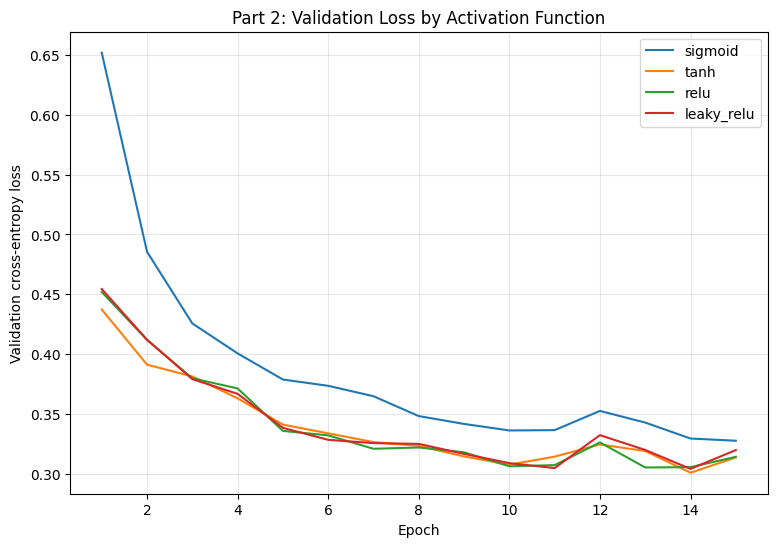

In [305]:

plt.figure(figsize=(9, 6))

for activation, result in activation_results.items():

    history = result["history"]

    plt.plot(
        range(1, len(history["val_loss"]) + 1),
        history["val_loss"],
        label=activation
    )

plt.xlabel("Epoch")
plt.ylabel("Validation cross-entropy loss")
plt.title("Part 2: Validation Loss by Activation Function")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [306]:

gradient_table = pd.DataFrame({
    "Activation": [
        "Sigmoid",
        "ReLU"
    ],
    "Mean abs gradient - Epoch 1": [
        activation_results["sigmoid"]["history"]["gradient_epoch_1"],
        activation_results["relu"]["history"]["gradient_epoch_1"]
    ],
    "Mean abs gradient - Final": [
        activation_results["sigmoid"]["history"]["gradient_final"],
        activation_results["relu"]["history"]["gradient_final"]
    ]
})

display(gradient_table)

,Activation,Mean abs gradient - Epoch 1,Mean abs gradient - Final
0,Sigmoid,0.000058,0.000226
1,ReLU,0.000504,0.000563


In [307]:

relu_model = activation_results["relu"]["model"]

relu_model.eval()

# Take one validation batch
val_loader_for_dead = DataLoader(
    TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    ),
    batch_size=256,
    shuffle=False
)

X_dead, _ = next(iter(val_loader_for_dead))
X_dead = X_dead.to(device)

with torch.no_grad():

    hidden = F.relu(
        relu_model.fc1(X_dead)
    )

# A hidden unit is dead if it outputs zero
# for EVERY sample in the validation batch.
dead_units = (
    (hidden == 0).all(dim=0)
)

dead_percentage = (
    dead_units.float().mean().item() * 100
)

print(
    f"ReLU hidden units outputting zero for every "
    f"sample in validation batch: {dead_percentage:.2f}%"
)

ReLU hidden units outputting zero for every sample in validation batch: 6.64%


Vanishing gradients. At epoch 1, the sigmoid network's mean absolute first-layer gradient was 0.000058, roughly 9x smaller than the ReLU network's 0.000504 — sigmoid's saturation at initialization is already choking off the gradient signal reaching the first layer. By the final epoch the sigmoid gradient had grown to 0.000226 (still under half of ReLU's), while ReLU's gradient stayed roughly stable (0.000504 → 0.000563), confirming that ReLU does not suffer the same vanishing-gradient degradation across training.

Dead units. 6.64% of the first hidden layer's ReLU units output zero for every sample in the validation batch, meaning these units have permanently switched off and neither contribute to the forward pass nor receive gradient updates. This is a moderate rate of the "dying ReLU" phenomenon: it shows some capacity loss from large negative pre-activations combined with ReLU's zero gradient on the negative side, but it is not severe enough here to have crippled the network's overall accuracy.

Part 3-Loss Functions

In [308]:

class LossComparisonMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [309]:

def train_loss_comparison(loss_type, epochs=15, lr=0.001):

    torch.manual_seed(SEED)

    model = LossComparisonMLP().to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    train_loader, val_loader = create_loaders(
        X_train,
        y_train,
        X_val,
        y_val
    )

    history = {
        "loss": [],
        "accuracy": []
    }

    for epoch in range(epochs):

        model.train()

        epoch_loss = 0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(X_batch)

            if loss_type == "cross_entropy":

                loss = F.cross_entropy(
                    logits,
                    y_batch
                )

            elif loss_type == "mse":

                probabilities = F.softmax(
                    logits,
                    dim=1
                )

                targets = F.one_hot(
                    y_batch,
                    num_classes=10
                ).float()

                loss = F.mse_loss(
                    probabilities,
                    targets
                )

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * len(y_batch)

            correct += (
                logits.argmax(1) == y_batch
            ).sum().item()

            total += len(y_batch)

        history["loss"].append(
            epoch_loss / total
        )

        history["accuracy"].append(
            correct / total
        )

    return model, history

In [310]:
ce_model, ce_history = train_loss_comparison(
    "cross_entropy",
    epochs=15
)

mse_model, mse_history = train_loss_comparison(
    "mse",
    epochs=15
)

# Test accuracy as explicitly required by Part 3
def test_accuracy(model):

    model.eval()

    X_tensor = torch.tensor(
        X_test,
        dtype=torch.float32,
        device=device
    )

    y_tensor = torch.tensor(
        y_test,
        dtype=torch.long,
        device=device
    )

    with torch.no_grad():

        logits = model(X_tensor)

        predictions = logits.argmax(1)

        return (
            predictions == y_tensor
        ).float().mean().item()


ce_test_accuracy = test_accuracy(ce_model)
mse_test_accuracy = test_accuracy(mse_model)

print(
    f"Cross-entropy test accuracy: "
    f"{ce_test_accuracy:.4f}"
)

print(
    f"MSE test accuracy: "
    f"{mse_test_accuracy:.4f}"
)

Cross-entropy test accuracy: 0.8863
MSE test accuracy: 0.8912


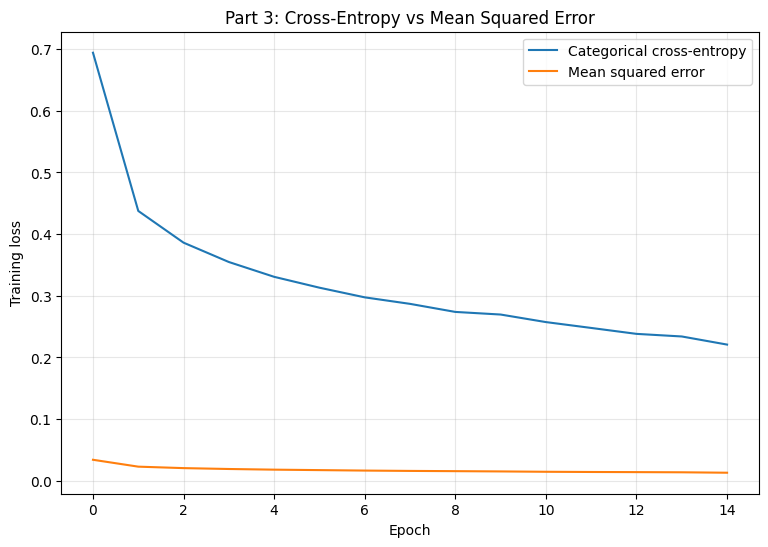

In [311]:

plt.figure(figsize=(9, 6))

plt.plot(
    ce_history["loss"],
    label="Categorical cross-entropy"
)

plt.plot(
    mse_history["loss"],
    label="Mean squared error"
)

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Part 3: Cross-Entropy vs Mean Squared Error")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Both losses reached comparable final test accuracy (88.63% cross-entropy vs 89.12% MSE), but cross-entropy reaches a low loss value in fewer epochs, which is visible in the training-loss plot above. This is because cross-entropy's gradient with respect to the logits is directly proportional to the prediction error, (softmax(z) - y), so a confidently wrong prediction produces a large gradient. MSE on softmax probabilities instead multiplies the error by the softmax derivative, which shrinks toward zero exactly when the model is confidently wrong (saturated probabilities near 0 or 1)- this extra vanishing term is what slows MSE's early-training convergence relative to cross-entropy.

In [312]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

diabetes = load_diabetes()

X_reg = diabetes.data.astype(np.float32)
y_reg = diabetes.target.astype(np.float32)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=SEED
)

scaler = StandardScaler()

X_reg_train = scaler.fit_transform(
    X_reg_train
).astype(np.float32)

X_reg_test = scaler.transform(
    X_reg_test
).astype(np.float32)

X_reg_train_tensor = torch.tensor(
    X_reg_train,
    dtype=torch.float32,
    device=device
)

y_reg_train_tensor = torch.tensor(
    y_reg_train,
    dtype=torch.float32,
    device=device
).reshape(-1, 1)

X_reg_test_tensor = torch.tensor(
    X_reg_test,
    dtype=torch.float32,
    device=device
)

class RegressionMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(10, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


reg_model = RegressionMLP().to(device)

optimizer = torch.optim.Adam(
    reg_model.parameters(),
    lr=0.001
)

criterion = nn.MSELoss()

for epoch in range(200):

    reg_model.train()

    optimizer.zero_grad()

    predictions = reg_model(
        X_reg_train_tensor
    )

    loss = criterion(
        predictions,
        y_reg_train_tensor
    )

    loss.backward()
    optimizer.step()

reg_model.eval()

with torch.no_grad():

    reg_predictions = (
        reg_model(
            X_reg_test_tensor
        )
        .cpu()
        .numpy()
        .flatten()
    )

reg_mse = mean_squared_error(
    y_reg_test,
    reg_predictions
)

reg_rmse = np.sqrt(reg_mse)

reg_mae = mean_absolute_error(
    y_reg_test,
    reg_predictions
)

print(f"Regression MSE:  {reg_mse:.4f}")
print(f"Regression RMSE: {reg_rmse:.4f}")
print(f"Regression MAE:  {reg_mae:.4f}")

Regression MSE:  5306.6606
Regression RMSE: 72.8468
Regression MAE:  54.3179


In [313]:

class OptimizerMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

In [314]:

def build_optimizer(
    name,
    model,
    lr
):

    if name == "SGD":

        return torch.optim.SGD(
            model.parameters(),
            lr=lr
        )

    elif name == "SGD + momentum":

        return torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=0.9
        )

    elif name == "RMSProp":

        return torch.optim.RMSprop(
            model.parameters(),
            lr=lr
        )

    elif name == "Adam":

        return torch.optim.Adam(
            model.parameters(),
            lr=lr
        )

    else:
        raise ValueError("Unknown optimizer")


def train_optimizer_model(
    optimizer_name,
    lr,
    epochs=15
):

    torch.manual_seed(SEED)
    np.random.seed(SEED)

    model = OptimizerMLP().to(device)

    optimizer = build_optimizer(
        optimizer_name,
        model,
        lr
    )

    criterion = nn.CrossEntropyLoss()

    train_loader, val_loader = create_loaders(
        X_train,
        y_train,
        X_val,
        y_val,
        batch_size=256
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    start_time = time.perf_counter()

    for epoch in range(epochs):

        model.train()

        loss_total = 0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(X_batch)

            loss = criterion(
                logits,
                y_batch
            )

            loss.backward()
            optimizer.step()

            loss_total += loss.item() * len(y_batch)

            correct += (
                logits.argmax(1) == y_batch
            ).sum().item()

            total += len(y_batch)

        train_loss = loss_total / total
        train_acc = correct / total

        val_loss, val_acc = evaluate_loader(
            model,
            val_loader
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    wall_time = time.perf_counter() - start_time

    # Epoch where validation accuracy first reaches 85%
    reached = np.where(
        np.array(history["val_acc"]) >= 0.85
    )[0]

    if len(reached) > 0:
        epochs_85 = int(reached[0] + 1)
    else:
        epochs_85 = np.nan

    return (
        model,
        history,
        epochs_85,
        history["val_acc"][-1],
        wall_time
    )


def evaluate_loader(model, loader):

    model.eval()

    criterion = nn.CrossEntropyLoss()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)

            loss = criterion(
                logits,
                y_batch
            )

            total_loss += (
                loss.item() * len(y_batch)
            )

            correct += (
                logits.argmax(1) == y_batch
            ).sum().item()

            total += len(y_batch)

    return total_loss / total, correct / total

In [315]:

optimizer_names = [
    "SGD",
    "SGD + momentum",
    "RMSProp",
    "Adam"
]

same_lr = 0.001

same_lr_results = {}
same_lr_histories = {}

for name in optimizer_names:

    print("\nTraining:", name)

    (
        model,
        history,
        epochs_85,
        final_val_acc,
        wall_time
    ) = train_optimizer_model(
        name,
        same_lr,
        epochs=15
    )

    same_lr_results[name] = {
        "model": model,
        "epochs_85": epochs_85,
        "final_val_accuracy": final_val_acc,
        "wall_time": wall_time
    }

    same_lr_histories[name] = history


Training: SGD

Training: SGD + momentum

Training: RMSProp

Training: Adam


In [316]:

tuned_learning_rates = {
    "SGD": 0.1,
    "SGD + momentum": 0.01,
    "RMSProp": 0.001,
    "Adam": 0.001
}

tuned_results = {}
tuned_histories = {}

for name in optimizer_names:

    lr = tuned_learning_rates[name]

    print(
        f"\nTraining {name} "
        f"with lr={lr}"
    )

    (
        model,
        history,
        epochs_85,
        final_val_acc,
        wall_time
    ) = train_optimizer_model(
        name,
        lr,
        epochs=15
    )

    tuned_results[name] = {
        "model": model,
        "learning_rate": lr,
        "epochs_85": epochs_85,
        "final_val_accuracy": final_val_acc,
        "wall_time": wall_time
    }

    tuned_histories[name] = history


Training SGD with lr=0.1

Training SGD + momentum with lr=0.01

Training RMSProp with lr=0.001

Training Adam with lr=0.001


In [317]:

part4_table = pd.DataFrame([
    {
        "Optimiser": name,
        "Learning rate": tuned_results[name]["learning_rate"],
        "Epochs to reach 85% validation accuracy":
            tuned_results[name]["epochs_85"],
        "Final validation accuracy":
            tuned_results[name]["final_val_accuracy"],
        "Wall-clock time (s)":
            tuned_results[name]["wall_time"]
    }
    for name in optimizer_names
])

display(part4_table)

,Optimiser,Learning rate,Epochs to reach 85% validation accuracy,Final validation accuracy,Wall-clock time (s)
0,SGD,0.100,8,0.866083,10.980032
1,SGD + momentum,0.010,7,0.871417,11.245722
2,RMSProp,0.001,3,0.877667,11.435295
3,Adam,0.001,2,0.889333,11.865252


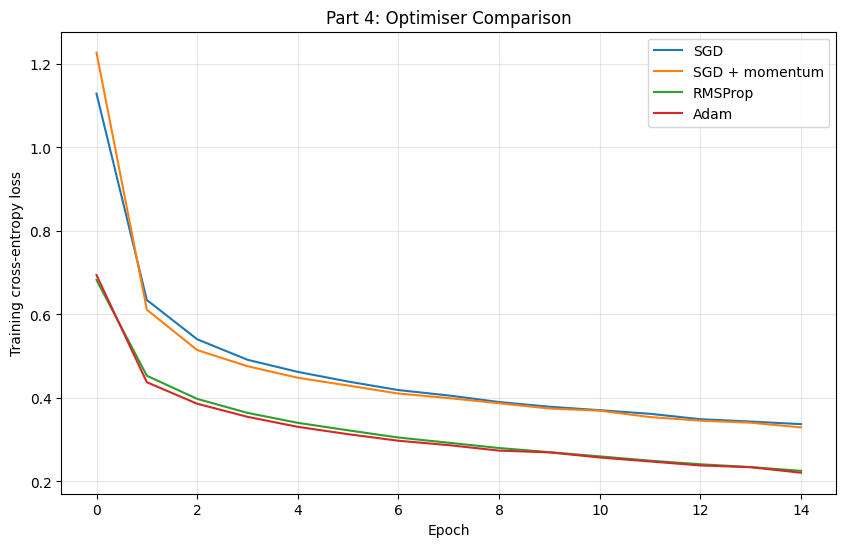

In [318]:

plt.figure(figsize=(10, 6))

for name in optimizer_names:

    history = tuned_histories[name]

    plt.plot(
        history["train_loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training cross-entropy loss")
plt.title("Part 4: Optimiser Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Adam is the optimiser I would choose here: at its tuned learning rate it reached 85% validation accuracy in just 2 epochs and finished with the highest final validation accuracy of the four (88.93%). While plain SGD tuned to lr = 0.100 successfully crossed the 85% threshold at epoch 8 and finished with 86.61% validation accuracy, Adam required a quarter of the epochs to reach the same benchmark. Adam's per-parameter adaptive learning rates and running momentum handle the ill-conditioned, high-dimensional gradient landscape of a flattened-pixel MLP far better than fixed-step SGD, and RMSProp's rapid convergence (85% in 3 epochs, 87.77% final) confirms that adaptive step-size mechanisms provide a distinct optimization advantage over non-adaptive updates.

Part 5

In [319]:

X_2000, _, y_2000, _ = train_test_split(
    X_train,
    y_train,
    train_size=2000,
    stratify=y_train,
    random_state=SEED
)

X_train_2000, X_val_2000, y_train_2000, y_val_2000 = train_test_split(
    X_2000,
    y_2000,
    test_size=0.20,
    stratify=y_2000,
    random_state=SEED
)

print("Training samples:", len(X_train_2000))
print("Validation samples:", len(X_val_2000))

Training samples: 1600
Validation samples: 400


In [320]:

class LargeMLP(nn.Module):

    def __init__(
        self,
        dropout=0.0,
        batch_norm=False
    ):

        super().__init__()

        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 512)

        self.out = nn.Linear(512, 10)

        if batch_norm:
            self.bn1 = nn.BatchNorm1d(512)
            self.bn2 = nn.BatchNorm1d(512)
            self.bn3 = nn.BatchNorm1d(512)
            self.bn4 = nn.BatchNorm1d(512)
        else:
            self.bn1 = nn.Identity()
            self.bn2 = nn.Identity()
            self.bn3 = nn.Identity()
            self.bn4 = nn.Identity()

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)

        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)

        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)

        x = F.relu(self.bn4(self.fc4(x)))
        x = self.dropout(x)

        x = self.out(x)
        return x

In [321]:

def train_large_model(
    X_tr,
    y_tr,
    X_va,
    y_va,
    dropout=0.0,
    weight_decay=0.0,
    l1_lambda=0.0,
    batch_norm=False,
    epochs=60,
    lr=0.001,
    patience=None,
    augmentation=False, 
    batch_size=128  
):

    torch.manual_seed(SEED)
    np.random.seed(SEED)

    model = LargeMLP(
        dropout=dropout,
        batch_norm=batch_norm
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    criterion = nn.CrossEntropyLoss()

    train_dataset = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.long)
    )

    val_dataset = TensorDataset(
        torch.tensor(X_va, dtype=torch.float32),
        torch.tensor(y_va, dtype=torch.long)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED)
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=256,
        shuffle=False
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0
    stopped_epoch = epochs

    for epoch in range(epochs):

        model.train()

        total_loss = 0
        total_correct = 0
        total = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Data augmentation
            
            if augmentation:

                images = X_batch.view(
                    -1, 1, 28, 28
                )

                augmented_images = []

                for image in images:

                    # Random horizontal flip
                    if random.random() < 0.5:
                        image = torch.flip(
                            image,
                            dims=[2]
                        )

                    # Random rotation: -10 to +10 degrees
                    angle = random.uniform(
                        -10,
                        10
                    )

                    image = TF.rotate(
                        image,
                        angle=angle
                    )

                    augmented_images.append(
                        image
                    )

                X_batch = torch.stack(
                    augmented_images
                ).view(-1, 784)

            optimizer.zero_grad()

            logits = model(X_batch)

            loss = criterion(
                logits,
                y_batch
            )

            # L1 regularisation

            if l1_lambda > 0:

                l1_penalty = torch.tensor(
                    0.0,
                    device=device
                )

                for parameter in model.parameters():

                    if parameter.requires_grad:

                        l1_penalty += torch.sum(
                            torch.abs(parameter)
                        )

                loss = loss + (
                    l1_lambda * l1_penalty
                )

            loss.backward()
            optimizer.step()

            total_loss += (
                loss.item() * len(y_batch)
            )

            total_correct += (
                logits.argmax(1) == y_batch
            ).sum().item()

            total += len(y_batch)

        train_loss = total_loss / total
        train_acc = total_correct / total

        val_loss, val_acc = evaluate_large_model(
            model,
            val_loader
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # Early stopping

        if patience is not None:

            if val_loss < best_val_loss:

                best_val_loss = val_loss

                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }

                epochs_without_improvement = 0

            else:

                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:

                stopped_epoch = epoch + 1

                print(
                    f"Early stopping at epoch "
                    f"{stopped_epoch}"
                )

                break

    # Restore best model
    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    # Final accuracy
    train_loss, train_acc = evaluate_large_model(
        model,
        train_loader
    )

    val_loss, val_acc = evaluate_large_model(
        model,
        val_loader
    )

    return (
        model,
        history,
        train_acc,
        val_acc,
        stopped_epoch
    )


def evaluate_large_model(
    model,
    loader
):

    model.eval()

    criterion = nn.CrossEntropyLoss()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)

            loss = criterion(
                logits,
                y_batch
            )

            total_loss += (
                loss.item() * len(y_batch)
            )

            correct += (
                logits.argmax(1) == y_batch
            ).sum().item()

            total += len(y_batch)

    return (
        total_loss / total,
        correct / total
    )

In [322]:

overfit_model, overfit_history, overfit_train_acc, overfit_val_acc, _ = (
    train_large_model(
        X_train_2000,
        y_train_2000,
        X_val_2000,
        y_val_2000,
        epochs=60,
        lr=0.001
    )
)

overfit_gap = (
    overfit_train_acc
    - overfit_val_acc
)

print(
    f"Training accuracy: "
    f"{overfit_train_acc:.4f}"
)

print(
    f"Validation accuracy: "
    f"{overfit_val_acc:.4f}"
)

print(
    f"Generalisation gap: "
    f"{overfit_gap:.4f}"
)

if overfit_train_acc > 0.99:
    print("Training accuracy exceeds 99%: overfitting objective achieved.")
else:
    print("Training accuracy did not exceed 99%; consider increasing epochs.")

Training accuracy: 0.9981
Validation accuracy: 0.8250
Generalisation gap: 0.1731
Training accuracy exceeds 99%: overfitting objective achieved.


Loss separation epoch: 3


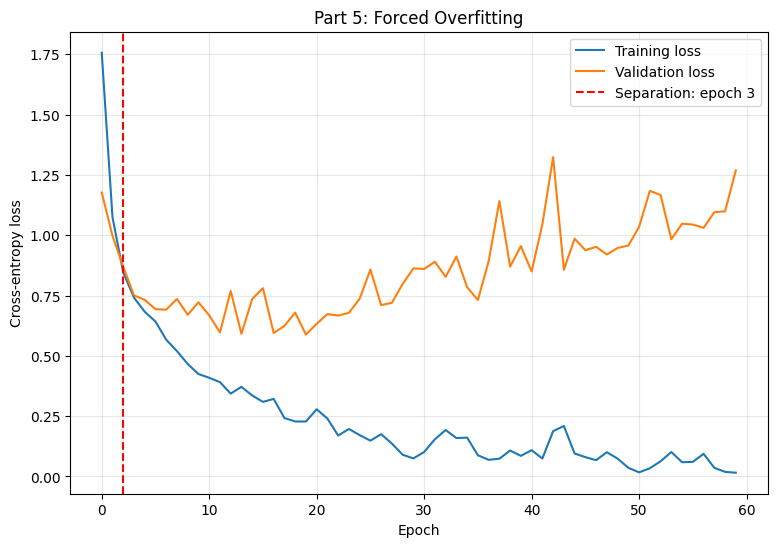

In [323]:

train_loss_array = np.array(
    overfit_history["train_loss"]
)

val_loss_array = np.array(
    overfit_history["val_loss"]
)

# Find first epoch where validation loss becomes
# persistently greater than training loss.
separation_epoch = None

for i in range(len(train_loss_array)):

    if val_loss_array[i] > train_loss_array[i]:

        separation_epoch = i + 1
        break

print(
    "Loss separation epoch:",
    separation_epoch
)

plt.figure(figsize=(9, 6))

plt.plot(
    train_loss_array,
    label="Training loss"
)

plt.plot(
    val_loss_array,
    label="Validation loss"
)

if separation_epoch is not None:

    plt.axvline(
        separation_epoch - 1,
        color="red",
        linestyle="--",
        label=f"Separation: epoch {separation_epoch}"
    )

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Part 5: Forced Overfitting")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

This model shows high variance, not high bias. Training accuracy of 99.81% shows the network fits the 2,000-sample training set almost perfectly, which rules out underfitting. The 17.31 percentage-point gap to validation accuracy (82.50%) shows that fit does not transfer to unseen data, and the training/validation loss curves diverge as early as epoch 3 - consistent with a high-capacity network (four hidden layers of 512 units) rapidly memorising training-specific patterns from too little data rather than learning generalisable structure.

Part 6

In [324]:

part6_results = []

part6_results.append({
    "Method": "Baseline (no regularisation)",
    "Setting": "None",
    "Train accuracy": overfit_train_acc,
    "Validation accuracy": overfit_val_acc,
    "Gap": overfit_gap
})

display(pd.DataFrame(part6_results))

,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Baseline (no regularisation),None,0.998125,0.825,0.173125


In [325]:

l2_values = [
    1e-5,
    1e-4,
    1e-3
]

l2_results = []

for lam in l2_values:

    print(
        "\nL2 lambda:",
        lam
    )

    model, history, train_acc, val_acc, stopped = (
        train_large_model(
            X_train_2000,
            y_train_2000,
            X_val_2000,
            y_val_2000,
            weight_decay=lam,
            epochs=60,
            lr=0.001
        )
    )

    l2_results.append({
        "Method": "L2 weight decay",
        "Setting": lam,
        "Train accuracy": train_acc,
        "Validation accuracy": val_acc,
        "Gap": train_acc - val_acc
    })

l2_df = pd.DataFrame(l2_results)

display(l2_df)


L2 lambda: 1e-05

L2 lambda: 0.0001

L2 lambda: 0.001


,Method,Setting,Train accuracy,Validation accuracy,Gap
0,L2 weight decay,0.00001,0.988750,0.8025,0.186250
1,L2 weight decay,0.00010,0.988125,0.8050,0.183125
2,L2 weight decay,0.00100,0.991875,0.8200,0.171875


In [326]:

l1_lambda = 0.0001

l1_model, l1_history, l1_train_acc, l1_val_acc, _ = (
    train_large_model(
        X_train_2000,
        y_train_2000,
        X_val_2000,
        y_val_2000,
        l1_lambda=l1_lambda,
        epochs=60,
        lr=0.001
    )
)

# Collect all weight values
weight_values = []

for name, parameter in l1_model.named_parameters():

    if "weight" in name:

        weight_values.append(
            parameter.detach()
            .cpu()
            .numpy()
            .ravel()
        )

all_weights = np.concatenate(
    weight_values
)

percentage_small = (
    np.mean(
        np.abs(all_weights) < 1e-3
    ) * 100
)

l1_gap = (
    l1_train_acc
    - l1_val_acc
)

print(
    f"L1 lambda: {l1_lambda}"
)

print(
    f"Weights below 1e-3: "
    f"{percentage_small:.2f}%"
)

print(
    f"Train accuracy: "
    f"{l1_train_acc:.4f}"
)

print(
    f"Validation accuracy: "
    f"{l1_val_acc:.4f}"
)

print(
    f"Gap: {l1_gap:.4f}"
)

L1 lambda: 0.0001
Weights below 1e-3: 84.82%
Train accuracy: 0.9800
Validation accuracy: 0.7925
Gap: 0.1875


In [327]:

dropout_values = [
    0.2,
    0.4,
    0.6
]

dropout_results = []

for rate in dropout_values:

    print(
        "\nDropout rate:",
        rate
    )

    model, history, train_acc, val_acc, _ = (
        train_large_model(
            X_train_2000,
            y_train_2000,
            X_val_2000,
            y_val_2000,
            dropout=rate,
            epochs=60,
            lr=0.001
        )
    )

    dropout_results.append({
        "Method": "Dropout",
        "Setting": rate,
        "Train accuracy": train_acc,
        "Validation accuracy": val_acc,
        "Gap": train_acc - val_acc
    })

dropout_df = pd.DataFrame(
    dropout_results
)

display(dropout_df)


Dropout rate: 0.2

Dropout rate: 0.4

Dropout rate: 0.6


,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Dropout,0.2,0.985625,0.8150,0.170625
1,Dropout,0.4,0.965625,0.8125,0.153125
2,Dropout,0.6,0.906250,0.8050,0.101250


In [328]:

bn_model, bn_history, bn_train_acc, bn_val_acc, _ = (
    train_large_model(
        X_train_2000,
        y_train_2000,
        X_val_2000,
        y_val_2000,
        batch_norm=True,
        epochs=60,
        lr=0.001,
        batch_size=256
    )
)

bn_gap = (
    bn_train_acc
    - bn_val_acc
)

print(
    f"Train accuracy: {bn_train_acc:.4f}"
)

print(
    f"Validation accuracy: {bn_val_acc:.4f}"
)

print(
    f"Gap: {bn_gap:.4f}"
)

Train accuracy: 0.9625
Validation accuracy: 0.7875
Gap: 0.1750


In [329]:

patience = 5

es_model, es_history, es_train_acc, es_val_acc, stopped_epoch = (
    train_large_model(
        X_train_2000,
        y_train_2000,
        X_val_2000,
        y_val_2000,
        epochs=60,
        lr=0.001,
        patience=patience
    )
)

es_gap = (
    es_train_acc
    - es_val_acc
)

print(
    f"Patience: {patience}"
)

print(
    f"Training stopped at epoch: "
    f"{stopped_epoch}"
)

print(
    f"Train accuracy: "
    f"{es_train_acc:.4f}"
)

print(
    f"Validation accuracy: "
    f"{es_val_acc:.4f}"
)

print(
    f"Gap: {es_gap:.4f}"
)

Early stopping at epoch 19
Patience: 5
Training stopped at epoch: 19
Train accuracy: 0.9050
Validation accuracy: 0.8075
Gap: 0.0975


In [330]:

aug_model, aug_history, aug_train_acc, aug_val_acc, _ = (
    train_large_model(
        X_train_2000,
        y_train_2000,
        X_val_2000,
        y_val_2000,
        epochs=60,
        lr=0.001,
        augmentation=True
    )
)

aug_gap = (
    aug_train_acc
    - aug_val_acc
)

print(
    f"Train accuracy: "
    f"{aug_train_acc:.4f}"
)

print(
    f"Validation accuracy: "
    f"{aug_val_acc:.4f}"
)

print(
    f"Gap: {aug_gap:.4f}"
)

Train accuracy: 0.9444
Validation accuracy: 0.8150
Gap: 0.1294


In [331]:

X_10k, _, y_10k, _ = train_test_split(
    X_train,
    y_train,
    train_size=10000,
    stratify=y_train,
    random_state=SEED
)

X_train_10k, X_val_10k, y_train_10k, y_val_10k = train_test_split(
    X_10k,
    y_10k,
    test_size=0.20,
    stratify=y_10k,
    random_state=SEED
)

model_10k, hist_10k, train_10k, val_10k, _ = (
    train_large_model(
        X_train_10k,
        y_train_10k,
        X_val_10k,
        y_val_10k,
        epochs=60,
        lr=0.001
    )
)

gap_10k = train_10k - val_10k

print("10,000 sample experiment")
print("Train accuracy:", train_10k)
print("Validation accuracy:", val_10k)
print("Gap:", gap_10k)

10,000 sample experiment
Train accuracy: 0.9935
Validation accuracy: 0.8745
Gap: 0.119


In [332]:

X_20k, _, y_20k, _ = train_test_split(
    X_train,
    y_train,
    train_size=20000,
    stratify=y_train,
    random_state=SEED
)

X_train_20k, X_val_20k, y_train_20k, y_val_20k = train_test_split(
    X_20k,
    y_20k,
    test_size=0.20,
    stratify=y_20k,
    random_state=SEED
)

model_20k, hist_20k, train_20k, val_20k, _ = (
    train_large_model(
        X_train_20k,
        y_train_20k,
        X_val_20k,
        y_val_20k,
        epochs=60,
        lr=0.001
    )
)

gap_20k = train_20k - val_20k

print("20,000 sample experiment")
print("Train accuracy:", train_20k)
print("Validation accuracy:", val_20k)
print("Gap:", gap_20k)

20,000 sample experiment
Train accuracy: 0.983625
Validation accuracy: 0.8785
Gap: 0.10512500000000002


In [333]:

part6_results = [
    {
        "Method": "Baseline (no regularisation)",
        "Setting": "None",
        "Train accuracy": overfit_train_acc,
        "Validation accuracy": overfit_val_acc,
        "Gap": overfit_gap
    }
]

# L2 rows
part6_results.extend(l2_results)

# L1
part6_results.append({
    "Method": "L1 penalty",
    "Setting": f"lambda={l1_lambda}; <1e-3={percentage_small:.2f}%",
    "Train accuracy": l1_train_acc,
    "Validation accuracy": l1_val_acc,
    "Gap": l1_gap
})

# Dropout
part6_results.extend(dropout_results)

# Batch normalization
part6_results.append({
    "Method": "Batch normalisation",
    "Setting": "BatchNorm",
    "Train accuracy": bn_train_acc,
    "Validation accuracy": bn_val_acc,
    "Gap": bn_gap
})

# Early stopping
part6_results.append({
    "Method": "Early stopping",
    "Setting": f"patience={patience}; stopped={stopped_epoch}",
    "Train accuracy": es_train_acc,
    "Validation accuracy": es_val_acc,
    "Gap": es_gap
})

# Data augmentation
part6_results.append({
    "Method": "Data augmentation",
    "Setting": "Flip + rotation ±10°",
    "Train accuracy": aug_train_acc,
    "Validation accuracy": aug_val_acc,
    "Gap": aug_gap
})

# More data
part6_results.append({
    "Method": "More training data",
    "Setting": "10,000 samples",
    "Train accuracy": train_10k,
    "Validation accuracy": val_10k,
    "Gap": gap_10k
})

part6_results.append({
    "Method": "More training data",
    "Setting": "20,000 samples",
    "Train accuracy": train_20k,
    "Validation accuracy": val_20k,
    "Gap": gap_20k
})

part6_df = pd.DataFrame(
    part6_results
)

display(
    part6_df.style.format({
        "Train accuracy": "{:.4f}",
        "Validation accuracy": "{:.4f}",
        "Gap": "{:.4f}"
    })
)

,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Baseline (no regularisation),None,0.9981,0.8250,0.1731
1,L2 weight decay,0.000010,0.9888,0.8025,0.1863
2,L2 weight decay,0.000100,0.9881,0.8050,0.1831
3,L2 weight decay,0.001000,0.9919,0.8200,0.1719
4,L1 penalty,lambda=0.0001; <1e-3=84.82%,0.9800,0.7925,0.1875
5,Dropout,0.200000,0.9856,0.8150,0.1706
6,Dropout,0.400000,0.9656,0.8125,0.1531
7,Dropout,0.600000,0.9062,0.8050,0.1012
8,Batch normalisation,BatchNorm,0.9625,0.7875,0.1750
9,Early stopping,patience=5; stopped=19,0.9050,0.8075,0.0975


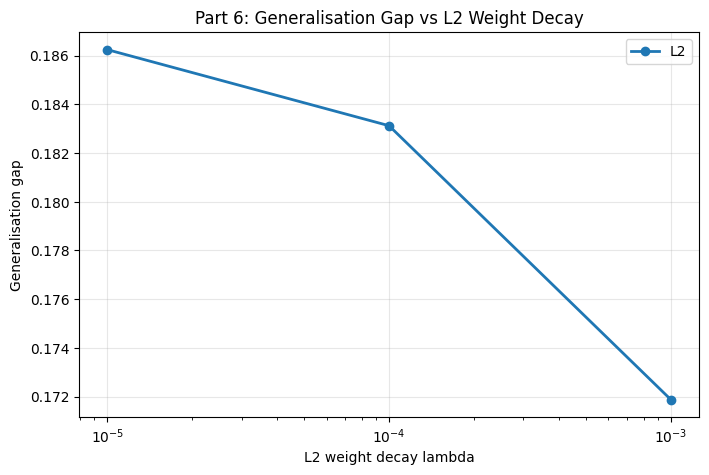

In [334]:

plt.figure(figsize=(8, 5))

plt.semilogx(
    l2_df["Setting"],
    l2_df["Gap"],
    marker="o",
    linewidth=2,
    label="L2"
)

plt.xlabel("L2 weight decay lambda")
plt.ylabel("Generalisation gap")
plt.title("Part 6: Generalisation Gap vs L2 Weight Decay")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

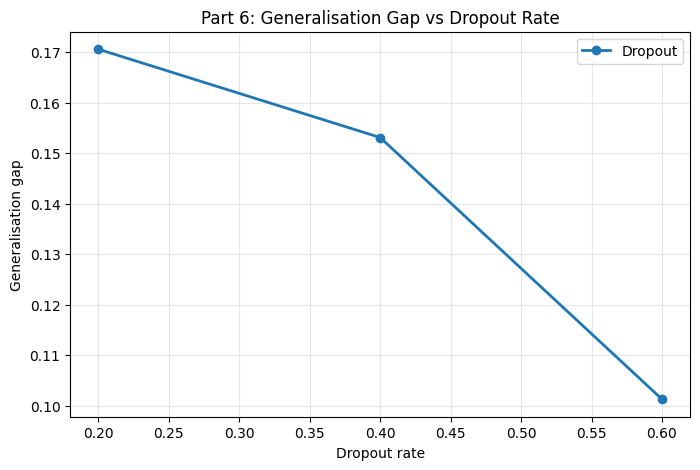

In [335]:
plt.figure(figsize=(8, 5))

plt.plot(
    dropout_df["Setting"],
    dropout_df["Gap"],
    marker="o",
    linewidth=2,
    label="Dropout"
)

plt.xlabel("Dropout rate")
plt.ylabel("Generalisation gap")
plt.title("Part 6: Generalisation Gap vs Dropout Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [336]:

comparison_df = part6_df.copy()

# Exclude baseline
non_baseline = comparison_df[
    comparison_df["Method"]
    != "Baseline (no regularisation)"
].copy()

# Smallest gap
best_gap_row = non_baseline.loc[
    non_baseline["Gap"].idxmin()
]

print("Smallest generalisation gap:")
display(best_gap_row.to_frame().T)

print("\nBaseline:")
display(
    comparison_df[
        comparison_df["Method"]
        == "Baseline (no regularisation)"
    ]
)

Smallest generalisation gap:


,Method,Setting,Train accuracy,Validation accuracy,Gap
9,Early stopping,patience=5; stopped=19,0.905,0.8075,0.0975



Baseline:


,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Baseline (no regularisation),None,0.998125,0.825,0.173125


By validation accuracy, more training data (20,000 samples) was the strongest fix: it raised validation accuracy from the baseline's 82.50% to 87.85% and cut the generalisation gap from 0.1731 to 0.1051, while training accuracy barely moved (99.81% → 98.36%)- the smallest training-accuracy cost of any method tested. Early stopping produced the single smallest gap (0.0975, stopped at epoch 19), and dropout at 0.6 came close (0.1012), but both did so by sacrificing far more training accuracy (90.50% and 90.62% respectively), closing the gap partly through underfitting rather than enhanced generalisation. L2 weight decay and batch normalisation barely moved the gap at all, and L1 at λ=0.0001 was too strong: it drove 84.82% of weights below 1e-3 but left the gap slightly wider than baseline (0.1875) while hurting both train and validation accuracy. Overall, scaling the training data gave the largest reduction in generalisation gap for the smallest loss in training accuracy

Part 7 

In [337]:

class CVMLP(nn.Module):

    def __init__(
        self,
        width=128,
        dropout=0.0
    ):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, width),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(width, width),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(width, 10)
        )

    def forward(self, x):
        return self.network(x)

In [338]:

search_space = {
    "learning_rate": [
        1e-4,
        3e-4,
        1e-3,
        3e-3,
        1e-2
    ],

    "hidden_width": [
        64,
        128,
        256,
        512
    ],

    "dropout": [
        0.0,
        0.2,
        0.4,
        0.5
    ]
}

rng = np.random.default_rng(SEED)

random_configs = []

for i in range(12):

    config = {
        "learning_rate": float(
            rng.choice(
                search_space["learning_rate"]
            )
        ),

        "hidden_width": int(
            rng.choice(
                search_space["hidden_width"]
            )
        ),

        "dropout": float(
            rng.choice(
                search_space["dropout"]
            )
        )
    }

    random_configs.append(config)

configs_df = pd.DataFrame(
    random_configs
)

display(configs_df)

,learning_rate,hidden_width,dropout
0,0.0001,512,0.4
1,0.0010,128,0.5
2,0.0001,256,0.0
3,0.0001,256,0.5
4,0.0030,512,0.4
5,0.0030,256,0.0
6,0.0100,128,0.4
7,0.0003,64,0.5
8,0.0030,256,0.2
9,0.0100,256,0.2


In [339]:

def cross_validate_configuration(
    X,
    y,
    config,
    n_splits=5,
    epochs=8,
    batch_size=256
):

    kfold = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=SEED
    )

    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(
        kfold.split(X),
        start=1
    ):

        print(
            f"    Fold {fold}/{n_splits}"
        )

        # Reset seed for reproducibility
        torch.manual_seed(
            SEED + fold
        )

        model = CVMLP(
            width=config["hidden_width"],
            dropout=config["dropout"]
        ).to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config["learning_rate"]
        )

        criterion = nn.CrossEntropyLoss()

        X_fold_train = X[train_idx]
        y_fold_train = y[train_idx]

        X_fold_val = X[val_idx]
        y_fold_val = y[val_idx]

        train_dataset = TensorDataset(
            torch.tensor(
                X_fold_train,
                dtype=torch.float32
            ),
            torch.tensor(
                y_fold_train,
                dtype=torch.long
            )
        )

        val_dataset = TensorDataset(
            torch.tensor(
                X_fold_val,
                dtype=torch.float32
            ),
            torch.tensor(
                y_fold_val,
                dtype=torch.long
            )
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            generator=torch.Generator().manual_seed(
                SEED + fold
            )
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False
        )

        for epoch in range(epochs):

            model.train()

            for X_batch, y_batch in train_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                optimizer.zero_grad()

                logits = model(X_batch)

                loss = criterion(
                    logits,
                    y_batch
                )

                loss.backward()
                optimizer.step()

        # Validation
        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                logits = model(X_batch)

                predictions = logits.argmax(
                    dim=1
                )

                correct += (
                    predictions == y_batch
                ).sum().item()

                total += len(y_batch)

        accuracy = correct / total

        fold_scores.append(
            accuracy
        )

        print(
            f"      Fold accuracy: "
            f"{accuracy:.4f}"
        )

        # Free GPU memory
        del model
        torch.cuda.empty_cache()

    return (
        np.mean(fold_scores),
        np.std(fold_scores),
        fold_scores
    )

In [340]:

cv_results = []

# For computational efficiency, use the training data only.
# Validation and test sets are NOT used here.

X_cv = X_train
y_cv = y_train

for config_number, config in enumerate(
    random_configs,
    start=1
):


    print(
        f"Configuration "
        f"{config_number}/12"
    )

    print(config)


    mean_score, std_score, fold_scores = (
        cross_validate_configuration(
            X_cv,
            y_cv,
            config,
            n_splits=5,
            epochs=8
        )
    )

    cv_results.append({
        "Configuration": config_number,
        "Learning rate": config["learning_rate"],
        "Hidden width": config["hidden_width"],
        "Dropout": config["dropout"],
        "Mean CV accuracy": mean_score,
        "Std CV accuracy": std_score,
        "Fold scores": fold_scores
    })

cv_results_df = pd.DataFrame(
    cv_results
)

cv_results_df = cv_results_df.sort_values(
    "Mean CV accuracy",
    ascending=False
).reset_index(drop=True)

display(
    cv_results_df[
        [
            "Configuration",
            "Learning rate",
            "Hidden width",
            "Dropout",
            "Mean CV accuracy",
            "Std CV accuracy"
        ]
    ]
)

Configuration 1/12
{'learning_rate': 0.0001, 'hidden_width': 512, 'dropout': 0.4}
    Fold 1/5
      Fold accuracy: 0.8502
    Fold 2/5
      Fold accuracy: 0.8476
    Fold 3/5
      Fold accuracy: 0.8532
    Fold 4/5
      Fold accuracy: 0.8562
    Fold 5/5
      Fold accuracy: 0.8573
Configuration 2/12
{'learning_rate': 0.001, 'hidden_width': 128, 'dropout': 0.5}
    Fold 1/5
      Fold accuracy: 0.8621
    Fold 2/5
      Fold accuracy: 0.8609
    Fold 3/5
      Fold accuracy: 0.8631
    Fold 4/5
      Fold accuracy: 0.8657
    Fold 5/5
      Fold accuracy: 0.8620
Configuration 3/12
{'learning_rate': 0.0001, 'hidden_width': 256, 'dropout': 0.0}
    Fold 1/5
      Fold accuracy: 0.8433
    Fold 2/5
      Fold accuracy: 0.8443
    Fold 3/5
      Fold accuracy: 0.8495
    Fold 4/5
      Fold accuracy: 0.8507
    Fold 5/5
      Fold accuracy: 0.8470
Configuration 4/12
{'learning_rate': 0.0001, 'hidden_width': 256, 'dropout': 0.5}
    Fold 1/5
      Fold accuracy: 0.8270
    Fold 2/5
    

,Configuration,Learning rate,Hidden width,Dropout,Mean CV accuracy,Std CV accuracy
0,12,0.0010,512,0.0,0.880896,0.005004
1,6,0.0030,256,0.0,0.880542,0.003603
2,9,0.0030,256,0.2,0.877438,0.005776
3,5,0.0030,512,0.4,0.869271,0.004127
4,2,0.0010,128,0.5,0.862771,0.001633
5,11,0.0010,64,0.0,0.861292,0.003744
6,10,0.0100,256,0.2,0.860313,0.004532
7,1,0.0001,512,0.4,0.852917,0.003631
8,3,0.0001,256,0.0,0.846958,0.002861
9,7,0.0100,128,0.4,0.840604,0.006340


In [341]:

top5_cv = cv_results_df.head(5).copy()

display(
    top5_cv[
        [
            "Configuration",
            "Learning rate",
            "Hidden width",
            "Dropout",
            "Mean CV accuracy",
            "Std CV accuracy"
        ]
    ].style.format({
        "Learning rate": "{:.5f}",
        "Dropout": "{:.2f}",
        "Mean CV accuracy": "{:.4f}",
        "Std CV accuracy": "{:.4f}"
    })
)

,Configuration,Learning rate,Hidden width,Dropout,Mean CV accuracy,Std CV accuracy
0,12,0.00100,512,0.00,0.8809,0.0050
1,6,0.00300,256,0.00,0.8805,0.0036
2,9,0.00300,256,0.20,0.8774,0.0058
3,5,0.00300,512,0.40,0.8693,0.0041
4,2,0.00100,128,0.50,0.8628,0.0016


In [342]:

best_config_row = cv_results_df.iloc[0]

selected_config = {
    "learning_rate": float(
        best_config_row["Learning rate"]
    ),
    "hidden_width": int(
        best_config_row["Hidden width"]
    ),
    "dropout": float(
        best_config_row["Dropout"]
    )
}

print("Selected configuration:")
print(selected_config)

print(
    "\nMean CV accuracy:",
    best_config_row["Mean CV accuracy"]
)

print(
    "CV standard deviation:",
    best_config_row["Std CV accuracy"]
)

Selected configuration:
{'learning_rate': 0.001, 'hidden_width': 512, 'dropout': 0.0}

Mean CV accuracy: 0.8808958333333333
CV standard deviation: 0.00500416493200081


In [343]:

regularisation_candidates = part6_df[
    part6_df["Method"]
    != "Baseline (no regularisation)"
].copy()

best_regularisation = regularisation_candidates.loc[
    regularisation_candidates["Validation accuracy"].idxmax()
]

print("Best Part 6 regularisation:")
display(
    best_regularisation.to_frame().T
)

Best Part 6 regularisation:


,Method,Setting,Train accuracy,Validation accuracy,Gap
12,More training data,"20,000 samples",0.983625,0.8785,0.105125


In [344]:

class FinalMLP(nn.Module):

    def __init__(
        self,
        width,
        dropout
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(784, width),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(width, width),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(width, 10)
        )

    def forward(self, x):

        return self.network(x)

In [345]:
torch.manual_seed(SEED)
np.random.seed(SEED)

final_model = FinalMLP(
    width=selected_config["hidden_width"],
    dropout=selected_config["dropout"]
).to(device)

# Determine L2 if that was the selected Part 6 method.
# Otherwise weight decay is zero.
selected_method = best_regularisation["Method"]
selected_setting = best_regularisation["Setting"]

final_weight_decay = 0.0

if selected_method == "L2 weight decay":
    final_weight_decay = float(
        best_regularisation["Setting"]
    )

optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=selected_config["learning_rate"],
    weight_decay=final_weight_decay
)

criterion = nn.CrossEntropyLoss()

full_train_dataset = TensorDataset(
    torch.tensor(
        X_train,
        dtype=torch.float32
    ),
    torch.tensor(
        y_train,
        dtype=torch.long
    )
)

full_train_loader = DataLoader(
    full_train_dataset,
    batch_size=256,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED)
)

final_history = []

FINAL_EPOCHS = 20

for epoch in range(FINAL_EPOCHS):

    final_model.train()

    epoch_loss = 0
    total = 0

    for X_batch, y_batch in full_train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = final_model(
            X_batch
        )

        loss = criterion(
            logits,
            y_batch
        )

        loss.backward()
        optimizer.step()

        epoch_loss += (
            loss.item() * len(y_batch)
        )

        total += len(y_batch)

    epoch_loss /= total

    final_history.append(
        epoch_loss
    )

    print(
        f"Epoch {epoch+1:02d}/{FINAL_EPOCHS} "
        f"- Loss: {epoch_loss:.4f}"
    )

Epoch 01/20 - Loss: 0.6018
Epoch 02/20 - Loss: 0.3997
Epoch 03/20 - Loss: 0.3543
Epoch 04/20 - Loss: 0.3220
Epoch 05/20 - Loss: 0.3014
Epoch 06/20 - Loss: 0.2853
Epoch 07/20 - Loss: 0.2696
Epoch 08/20 - Loss: 0.2590
Epoch 09/20 - Loss: 0.2469
Epoch 10/20 - Loss: 0.2399
Epoch 11/20 - Loss: 0.2268
Epoch 12/20 - Loss: 0.2183
Epoch 13/20 - Loss: 0.2072
Epoch 14/20 - Loss: 0.2029
Epoch 15/20 - Loss: 0.1879
Epoch 16/20 - Loss: 0.1871
Epoch 17/20 - Loss: 0.1730
Epoch 18/20 - Loss: 0.1760
Epoch 19/20 - Loss: 0.1649
Epoch 20/20 - Loss: 0.1614


In [346]:

final_model.eval()

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    test_logits = final_model(
        X_test_tensor
    )

    final_predictions = (
        test_logits
        .argmax(dim=1)
        .cpu()
        .numpy()
    )

# Metrics

final_test_accuracy = accuracy_score(
    y_test,
    final_predictions
)

macro_precision = precision_score(
    y_test,
    final_predictions,
    average="macro"
)

macro_recall = recall_score(
    y_test,
    final_predictions,
    average="macro"
)

macro_f1 = f1_score(
    y_test,
    final_predictions,
    average="macro"
)

print(
    f"Final test accuracy: "
    f"{final_test_accuracy:.4f}"
)

print(
    f"Macro precision: "
    f"{macro_precision:.4f}"
)

print(
    f"Macro recall: "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1: "
    f"{macro_f1:.4f}"
)

Final test accuracy: 0.8984
Macro precision: 0.8989
Macro recall: 0.8984
Macro F1: 0.8976


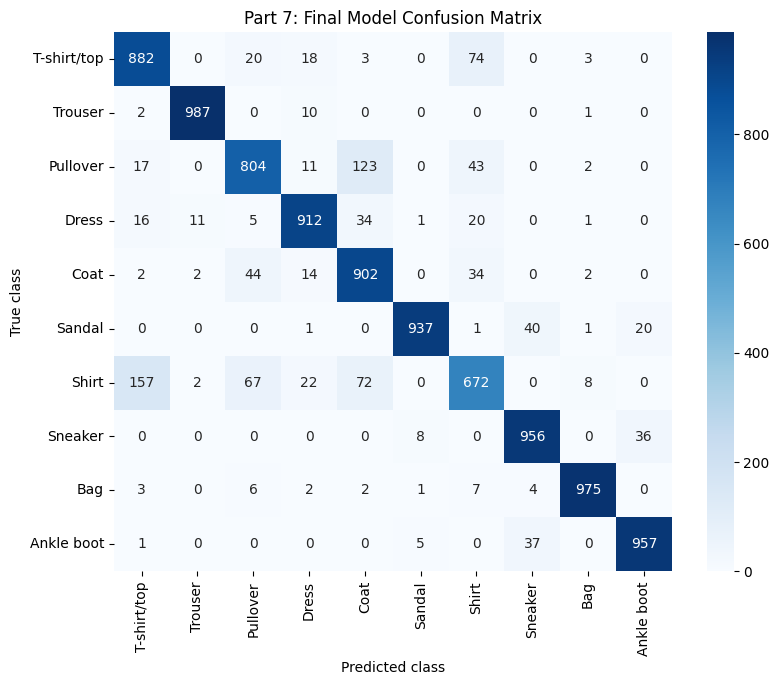

In [347]:
cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Part 7: Final Model Confusion Matrix")

plt.show()

In [348]:

relu_model_part2 = activation_results["relu"]["model"]

part2_relu_test_accuracy = test_accuracy(
    relu_model_part2
)

improvement_pp = (
    final_test_accuracy
    - part2_relu_test_accuracy
) * 100

print(
    f"Part 2 ReLU test accuracy: "
    f"{part2_relu_test_accuracy:.4f}"
)

print(
    f"Final tuned test accuracy: "
    f"{final_test_accuracy:.4f}"
)

print(
    f"Improvement: "
    f"{improvement_pp:.2f} percentage points"
)

if improvement_pp > 0:
    print(
        "The tuned model improved over the Part 2 baseline."
    )
else:
    print(
        "The tuned model did not improve over the Part 2 baseline."
    )

Part 2 ReLU test accuracy: 0.8863
Final tuned test accuracy: 0.8984
Improvement: 1.21 percentage points
The tuned model improved over the Part 2 baseline.


In [349]:

final_results = pd.DataFrame({
    "Metric": [
        "Test accuracy",
        "Macro precision",
        "Macro recall",
        "Macro F1",
        "Improvement over Part 2 (percentage points)"
    ],
    "Value": [
        final_test_accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        improvement_pp
    ]
})

display(
    final_results.style.format({
        "Value": "{:.4f}"
    })
)

,Metric,Value
0,Test accuracy,0.8984
1,Macro precision,0.8989
2,Macro recall,0.8984
3,Macro F1,0.8976
4,Improvement over Part 2 (percentage points),1.2100


In [350]:

distribution.to_csv(
    "class_distribution.csv",
    index=False
)

gradient_table.to_csv(
    "part2_gradient_results.csv",
    index=False
)

part4_table.to_csv(
    "part4_optimizer_summary.csv",
    index=False
)

part6_df.to_csv(
    "part6_regularisation_summary.csv",
    index=False
)

top5_cv[
    [
        "Configuration",
        "Learning rate",
        "Hidden width",
        "Dropout",
        "Mean CV accuracy",
        "Std CV accuracy"
    ]
].to_csv(
    "part7_top5_cv_configurations.csv",
    index=False
)

final_results.to_csv(
    "final_test_results.csv",
    index=False
)

print("All result tables saved.")

All result tables saved.


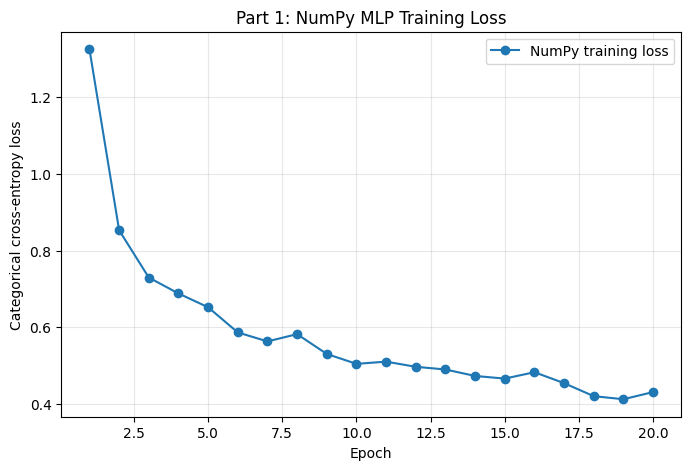

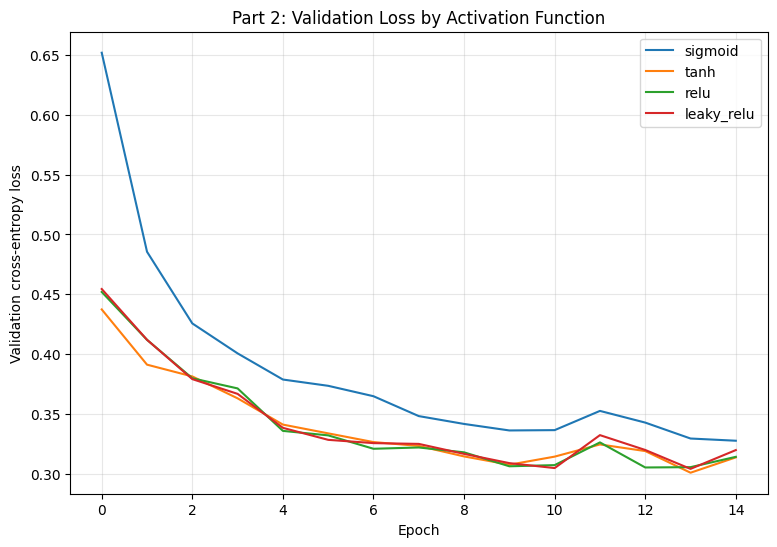

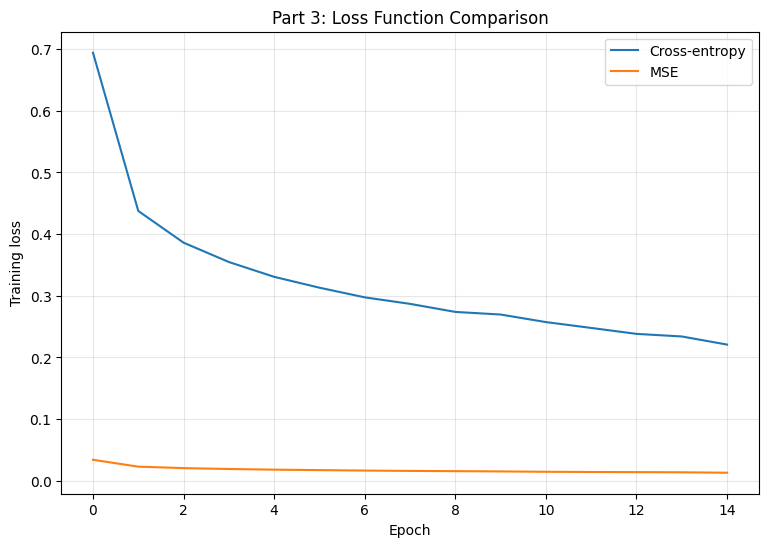

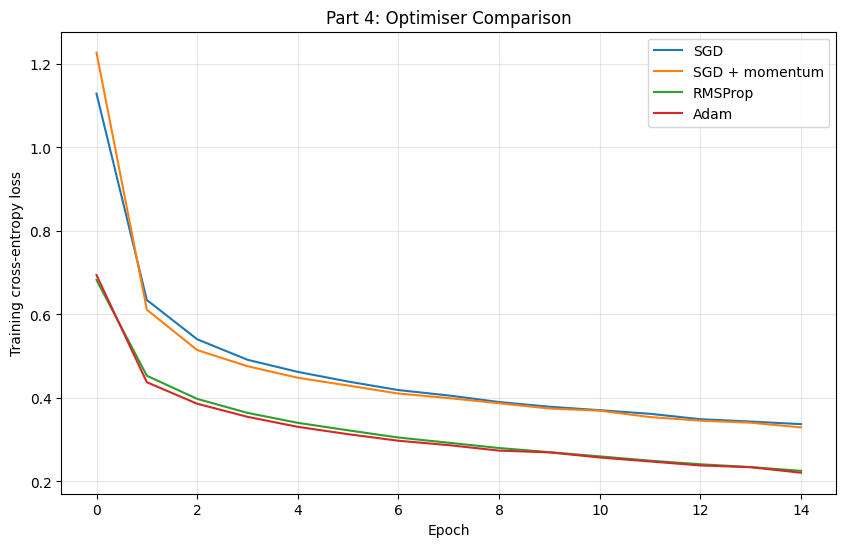

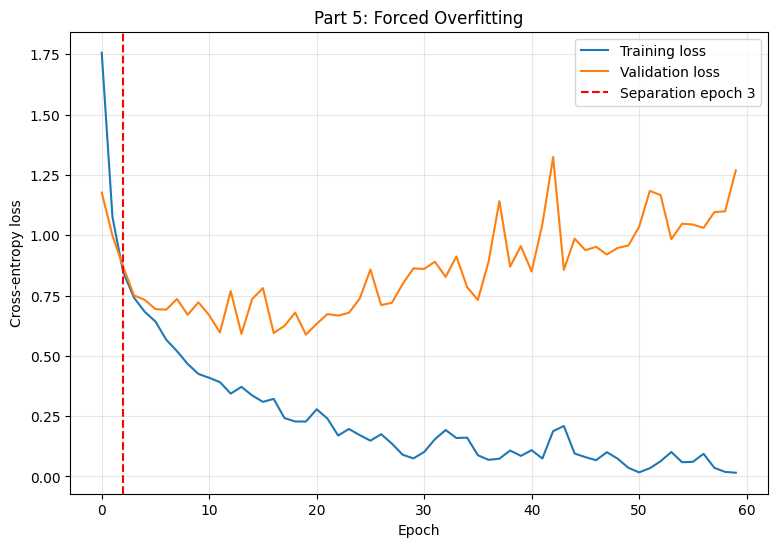

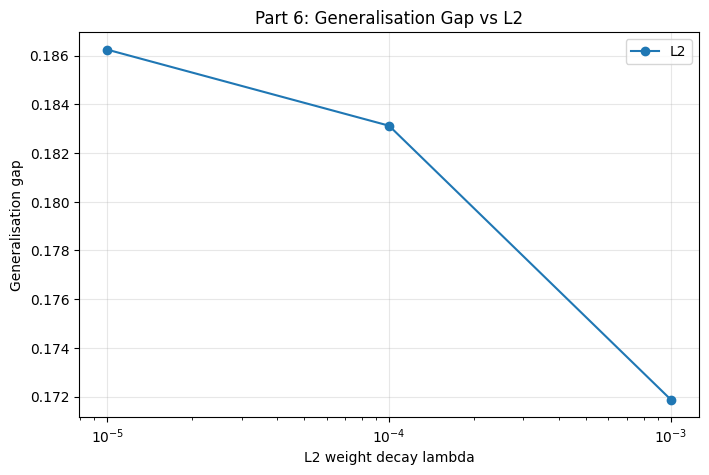

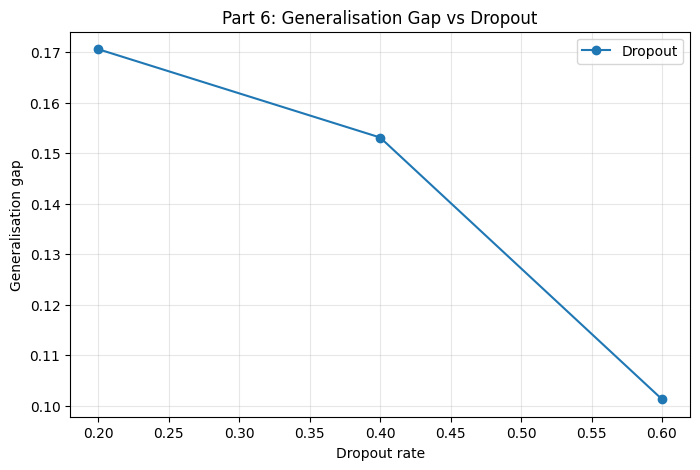

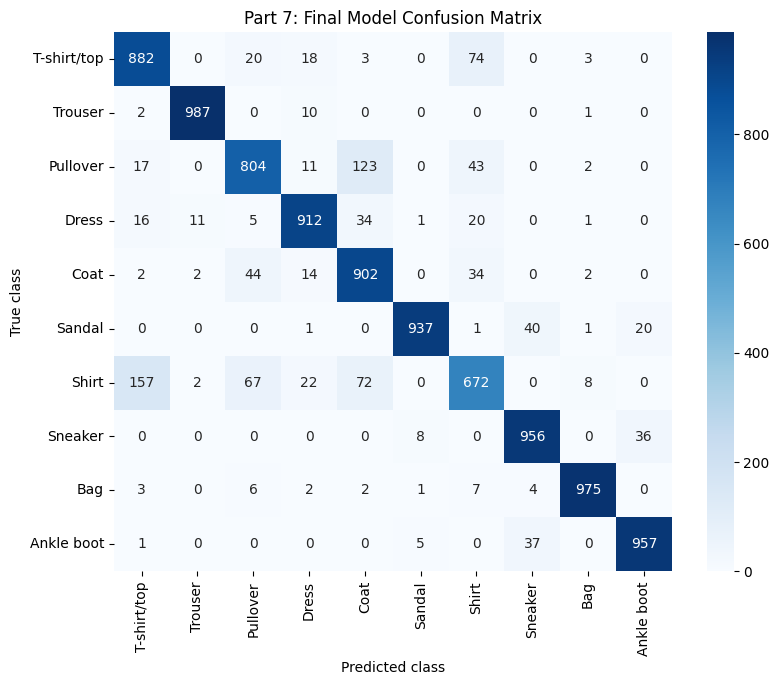

Part 1 - Backprop from scratch
Maximum gradient difference (NumPy vs PyTorch): 1.8569638743359818e-08

Part 2 - Activation study
Sigmoid mean |gradient| — epoch 1: 5.839253030221989e-05
Sigmoid mean |gradient| — final epoch: 0.00022577753074112981
ReLU mean |gradient| — epoch 1: 0.0005042977159548096
ReLU mean |gradient| — final epoch: 0.0005630643294004604
Dead ReLU units (% of hidden layer): 6.64%

Part 3 - Loss functions
Cross-entropy test accuracy: 0.8862999677658081
MSE test accuracy: 0.8912000060081482
Regression MSE: 5306.66064453125
Regression RMSE: 72.84683002390186
Regression MAE: 54.31790542602539

Part 4 - Optimiser comparison


,Optimiser,Learning rate,Epochs to reach 85% validation accuracy,Final validation accuracy,Wall-clock time (s)
0,SGD,0.100,8,0.866083,10.980032
1,SGD + momentum,0.010,7,0.871417,11.245722
2,RMSProp,0.001,3,0.877667,11.435295
3,Adam,0.001,2,0.889333,11.865252



Part 5 - Forced overfitting
Training accuracy: 0.998125
Validation accuracy: 0.825
Generalisation gap: 0.17312500000000008
Loss separation epoch: 3

Part 6 - Regularisation study


,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Baseline (no regularisation),None,0.998125,0.8250,0.173125
1,L2 weight decay,0.00001,0.988750,0.8025,0.186250
2,L2 weight decay,0.0001,0.988125,0.8050,0.183125
3,L2 weight decay,0.001,0.991875,0.8200,0.171875
4,L1 penalty,lambda=0.0001; <1e-3=84.82%,0.980000,0.7925,0.187500
5,Dropout,0.2,0.985625,0.8150,0.170625
6,Dropout,0.4,0.965625,0.8125,0.153125
7,Dropout,0.6,0.906250,0.8050,0.101250
8,Batch normalisation,BatchNorm,0.962500,0.7875,0.175000
9,Early stopping,patience=5; stopped=19,0.905000,0.8075,0.097500



Part 7 - Hyperparameter tuning and final evaluation
Selected configuration: {'learning_rate': 0.001, 'hidden_width': 512, 'dropout': 0.0}
Selected configuration mean CV accuracy: 0.8808958333333333
Best Part 6 regularisation carried forward: More training data - 20,000 samples
Final test accuracy: 0.8984
Macro precision: 0.8989201862919168
Macro recall: 0.8984
Macro F1: 0.8975567884913247
Improvement over Part 2 ReLU baseline (pp): 1.210003223419187


In [351]:

# Part 1
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, epochs + 1),
    numpy_losses,
    marker="o",
    label="NumPy training loss"
)
plt.xlabel("Epoch")
plt.ylabel("Categorical cross-entropy loss")
plt.title("Part 1: NumPy MLP Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(
    "part1_numpy_training_loss.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# Part 2
plt.figure(figsize=(9, 6))

for activation, result in activation_results.items():

    plt.plot(
        result["history"]["val_loss"],
        label=activation
    )

plt.xlabel("Epoch")
plt.ylabel("Validation cross-entropy loss")
plt.title("Part 2: Validation Loss by Activation Function")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(
    "part2_activation_validation_loss.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# Part 3
plt.figure(figsize=(9, 6))

plt.plot(
    ce_history["loss"],
    label="Cross-entropy"
)

plt.plot(
    mse_history["loss"],
    label="MSE"
)

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Part 3: Loss Function Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(
    "part3_loss_comparison.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# Part 4
plt.figure(figsize=(10, 6))

for name in optimizer_names:

    plt.plot(
        tuned_histories[name]["train_loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training cross-entropy loss")
plt.title("Part 4: Optimiser Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(
    "part4_optimizer_comparison.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# Part 5
plt.figure(figsize=(9, 6))

plt.plot(
    overfit_history["train_loss"],
    label="Training loss"
)

plt.plot(
    overfit_history["val_loss"],
    label="Validation loss"
)

if separation_epoch is not None:

    plt.axvline(
        separation_epoch - 1,
        color="red",
        linestyle="--",
        label=f"Separation epoch {separation_epoch}"
    )

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Part 5: Forced Overfitting")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(
    "part5_forced_overfitting.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# Part 6 L2
plt.figure(figsize=(8, 5))

plt.semilogx(
    l2_df["Setting"],
    l2_df["Gap"],
    marker="o",
    label="L2"
)

plt.xlabel("L2 weight decay lambda")
plt.ylabel("Generalisation gap")
plt.title("Part 6: Generalisation Gap vs L2")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(
    "part6_l2_gap.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# Part 6 dropout
plt.figure(figsize=(8, 5))

plt.plot(
    dropout_df["Setting"],
    dropout_df["Gap"],
    marker="o",
    label="Dropout"
)

plt.xlabel("Dropout rate")
plt.ylabel("Generalisation gap")
plt.title("Part 6: Generalisation Gap vs Dropout")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(
    "part6_dropout_gap.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# Part 7 confusion matrix
plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Part 7: Final Model Confusion Matrix")

plt.savefig(
    "part7_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# Final report values to extract
# After executing the notebook, copy these into the Word summary.


print("Part 1 - Backprop from scratch")

print("Maximum gradient difference (NumPy vs PyTorch):",
      max(diff_W1, diff_b1, diff_W2, diff_b2))

print()

print("Part 2 - Activation study")

print("Sigmoid mean |gradient| — epoch 1:",
      activation_results["sigmoid"]["history"]["gradient_epoch_1"])
print("Sigmoid mean |gradient| — final epoch:",
      activation_results["sigmoid"]["history"]["gradient_final"])
print("ReLU mean |gradient| — epoch 1:",
      activation_results["relu"]["history"]["gradient_epoch_1"])
print("ReLU mean |gradient| — final epoch:",
      activation_results["relu"]["history"]["gradient_final"])
print("Dead ReLU units (% of hidden layer):", f"{dead_percentage:.2f}%")

print()

print("Part 3 - Loss functions")

print("Cross-entropy test accuracy:", ce_test_accuracy)
print("MSE test accuracy:", mse_test_accuracy)
print("Regression MSE:", reg_mse)
print("Regression RMSE:", reg_rmse)
print("Regression MAE:", reg_mae)

print()

print("Part 4 - Optimiser comparison")

display(part4_table)

print()

print("Part 5 - Forced overfitting")

print("Training accuracy:", overfit_train_acc)
print("Validation accuracy:", overfit_val_acc)
print("Generalisation gap:", overfit_gap)
print("Loss separation epoch:", separation_epoch)

print()

print("Part 6 - Regularisation study")

display(part6_df)

print()

print("Part 7 - Hyperparameter tuning and final evaluation")

print("Selected configuration:", selected_config)
print("Selected configuration mean CV accuracy:", best_config_row["Mean CV accuracy"])
print("Best Part 6 regularisation carried forward:", selected_method, "-", selected_setting)
print("Final test accuracy:", final_test_accuracy)
print("Macro precision:", macro_precision)
print("Macro recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Improvement over Part 2 ReLU baseline (pp):", improvement_pp)